In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Download latest version
path = kagglehub.dataset_download("nalisha/car-price-prediction-dataset")

# Kalau dataset punya beberapa file, kamu bisa cek isi folder path dengan ini
df = pd.read_csv(os.path.join(path, "car_price_prediction_with_missing.csv"))

# Set tema visualisasi agar terlihat clean dan profesional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
# Cek data apakah sudah masuk atau belum
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


# Data Cleaning

In [14]:
# menampilkan baris yang punya missing sebagian, bukan semua.
df[df.isnull().any(axis=1)] 


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model


In [22]:
# Cek Missing Value
df.isna().sum()

Car ID          250
Brand           250
Year            250
Engine Size     250
Fuel Type       250
Transmission    250
Mileage         250
Condition       250
Price           250
Model           250
dtype: int64

In [23]:
# Karena setelah di cek ada 250 rows yang miss. Maka, hapus semua baris yang kosong (missing semua) dan cek hasilnya
df = df.dropna(how="all")
print(df.shape) 

(2250, 10)


In [8]:
# Standardisasi nama kolom (menghilangkan spasi berlebih di awal/akhir)
df.columns = df.columns.str.strip()

In [9]:
# Cek & Tangani Missing Values (jika ada)
missing_data = df.isnull().sum()
print("-> Pengecekan Missing Values per Kolom:")
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "   Tidak ada missing values.")

-> Pengecekan Missing Values per Kolom:
   Tidak ada missing values.


In [10]:
# Pastikan tipe data sesuai (mengubah float tahun/ID menjadi integer)
if 'Year' in df.columns:
    df['Year'] = df['Year'].astype(int)
if 'Car ID' in df.columns:
    df['Car ID'] = df['Car ID'].astype(int)
        
print(f"-> Data berhasil dibersihkan. Total: {df.shape[0]} baris, {df.shape[1]} kolom.\n")

-> Data berhasil dibersihkan. Total: 2250 baris, 10 kolom.



In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 2250 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2250 non-null   int64  
 1   Brand         2250 non-null   str    
 2   Year          2250 non-null   int64  
 3   Engine Size   2250 non-null   float64
 4   Fuel Type     2250 non-null   str    
 5   Transmission  2250 non-null   str    
 6   Mileage       2250 non-null   float64
 7   Condition     2250 non-null   str    
 8   Price         2250 non-null   float64
 9   Model         2250 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 193.4 KB


## Exploratory Data Analyst

In [18]:
print("\nStatistik Kolom Numerik")
print(df.describe().round(2))
print("\nStatistik Kolom Kategorikal")
print(df.describe(include=["object", "string"]))
print("\n")


Statistik Kolom Numerik
        Car ID     Year  Engine Size    Mileage     Price
count  2250.00  2250.00      2250.00    2250.00   2250.00
mean   1251.24  2011.58         3.49  150236.18  52506.87
std     725.64     6.98         1.43   88150.75  27232.42
min       1.00  2000.00         1.00      15.00   5011.27
25%     627.25  2005.00         2.30   71178.50  28985.05
50%    1249.50  2012.00         3.45  149762.00  53485.24
75%    1875.25  2018.00         4.70  226299.00  75560.34
max    2500.00  2023.00         6.00  299967.00  99982.59

Statistik Kolom Kategorikal
         Brand Fuel Type Transmission Condition    Model
count     2250      2250         2250      2250     2250
unique       7         4            2         3       28
top     Toyota    Diesel       Manual      Used  Corolla
freq       346       587         1184       769       97




# Business Insight 

In [24]:
# 1. Rata-rata harga per Brand
avg_price_brand = df.groupby('Brand')['Price'].mean().sort_values(ascending=False)
print("Top Brand dengan Rata-rata Harga Tertinggi:")
print(avg_price_brand.map('USD {:,.2f}'.format))


Top Brand dengan Rata-rata Harga Tertinggi:
Brand
BMW         USD 54,153.25
Mercedes    USD 53,079.99
Tesla       USD 52,677.92
Audi        USD 52,255.47
Toyota      USD 51,942.35
Honda       USD 51,812.37
Ford        USD 51,551.94
Name: Price, dtype: str


In [28]:
# 2. Resale Value berdasarkan Kondisi Mobil
avg_price_condition = df.groupby('Condition')['Price'].mean().sort_values(ascending=False)
print("Pengaruh Kondisi Fisik terhadap Nilai Jual Mobil:")
print(avg_price_condition.map('USD {:,.2f}'.format))

Pengaruh Kondisi Fisik terhadap Nilai Jual Mobil:
Condition
Like New    USD 53,002.93
Used        USD 52,608.00
New         USD 51,897.59
Name: Price, dtype: str


In [ ]:
# 3. Matriks Harga berdasarkan Bahan Bakar & Transmisi
pivot_fuel_trans = df.pivot_table(values='Price', index='Fuel Type', columns='Transmission', aggfunc='mean')
print("3. Matriks Kombinasi Bahan Bakar vs Transmisi terhadap Harga:")
print(pivot_fuel_trans.round(2))

3. Matriks Kombinasi Bahan Bakar vs Transmisi terhadap Harga:
Transmission  Automatic    Manual
Fuel Type                        
Diesel         52970.67  56569.74
Electric       52008.40  49712.49
Hybrid         52513.59  52676.28
Petrol         51605.96  51646.88


# Graphic of Business

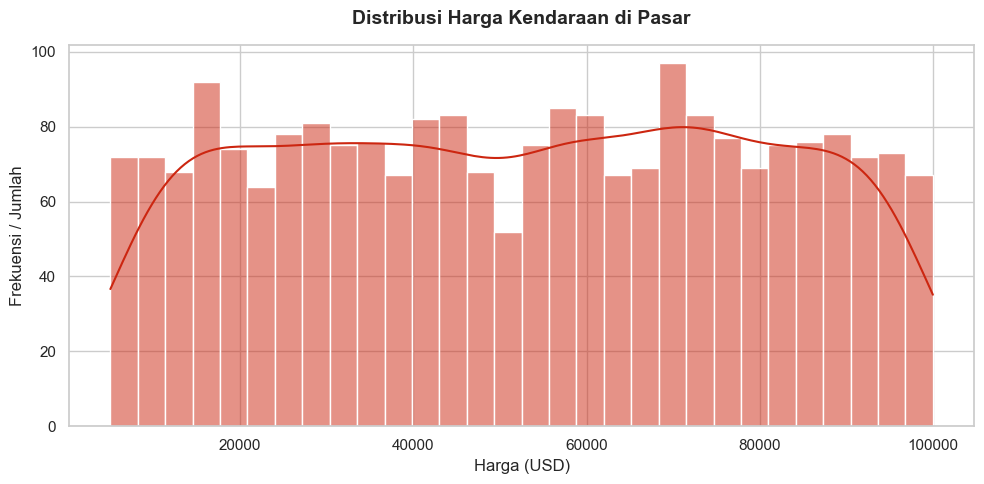

In [ ]:
# Plot 1: Distribusi Harga Mobil (Melihat skewness pasar)
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], kde=True, color="#cc2610", bins=30)
plt.title('Distribusi Harga Kendaraan di Pasar', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Harga (USD)', fontsize=12)
plt.ylabel('Frekuensi / Jumlah', fontsize=12)
plt.tight_layout()
plt.show()

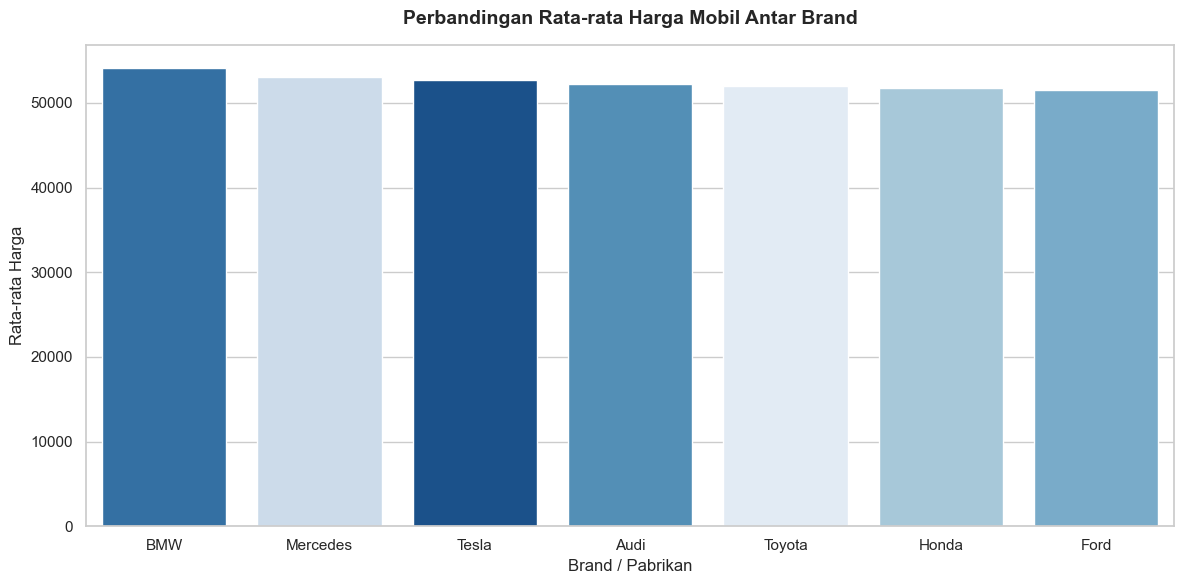

In [ ]:
# Plot 2: Rata-rata Harga per Brand
plt.figure(figsize=(12, 6))
brand_order = df.groupby('Brand')['Price'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Brand', hue='Brand', legend=False, y='Price', order=brand_order, palette='Blues_r', errorbar=None)
plt.title('Perbandingan Rata-rata Harga Mobil Antar Brand', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Brand / Pabrikan', fontsize=12)
plt.ylabel('Rata-rata Harga', fontsize=12)
plt.tight_layout()
plt.show()

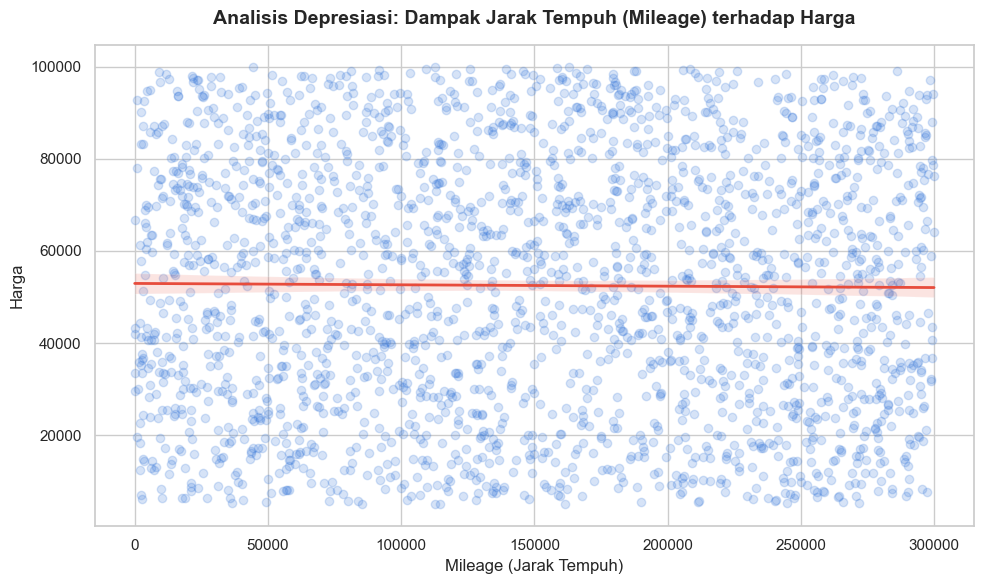

In [ ]:
# Plot 3: Dampak Jarak Tempuh (Mileage) Terhadap Harga Mobil (Depresiasi)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Mileage', y='Price', 
    scatter_kws={'alpha':0.2, 'color':"#3576d9"}, 
    line_kws={'color':'#e74c3c', 'linewidth':2})
plt.title('Analisis Depresiasi: Dampak Jarak Tempuh (Mileage) terhadap Harga', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mileage (Jarak Tempuh)', fontsize=12)
plt.ylabel('Harga', fontsize=12)
plt.tight_layout()

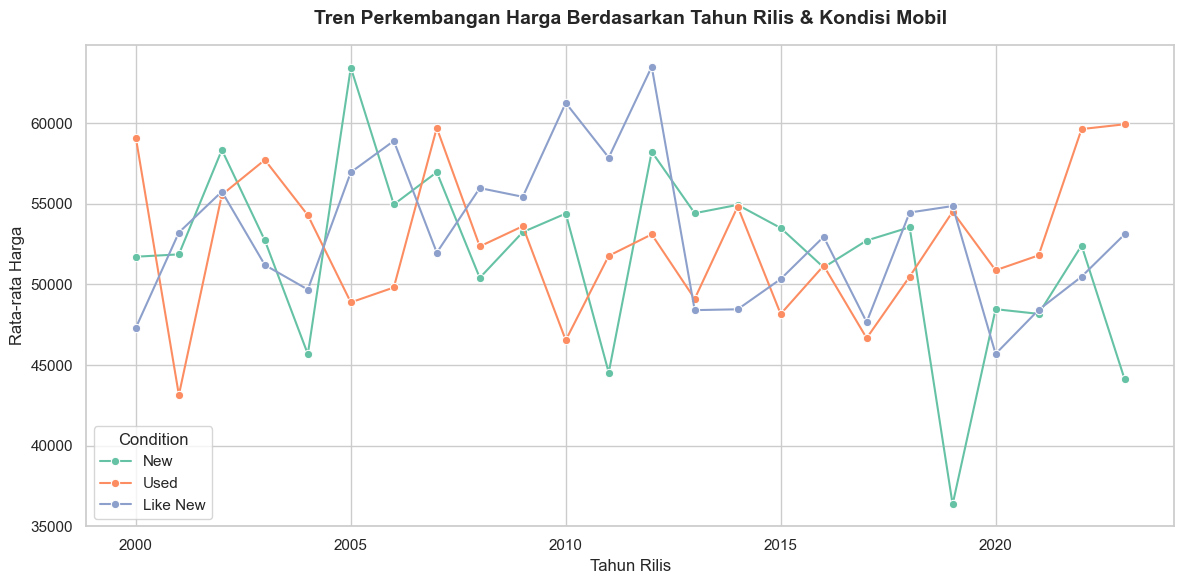

In [ ]:
# Plot 4: Tren Harga Berdasarkan Tahun Rilis & Kondisi
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Price', hue='Condition', marker='o', errorbar=None, palette='Set2')
plt.title('Tren Perkembangan Harga Berdasarkan Tahun Rilis & Kondisi Mobil', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahun Rilis', fontsize=12)
plt.ylabel('Rata-rata Harga', fontsize=12)
plt.tight_layout()

# Descriptive Analytics With Regression and ANOVA 
# What's The Effect on Price by Dataset?

In [33]:
# Hitung jumlah sample per kondisi karena ada data bias di kondisi dan price

df['Condition'].value_counts()

Condition
Used        769
Like New    746
New         735
Name: count, dtype: int64

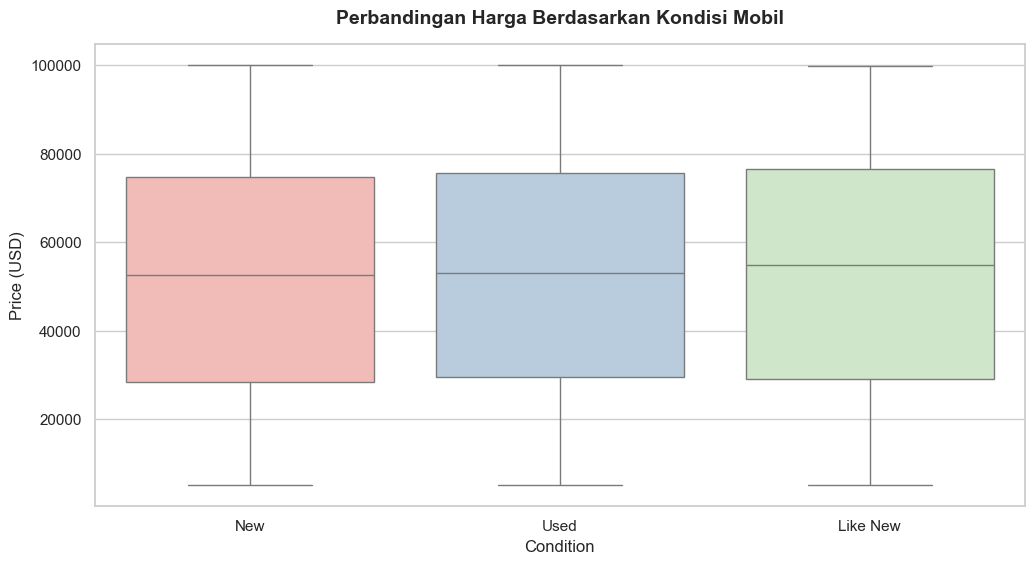

In [ ]:
# Gunakan boxplot untuk melihat distribusi harga berdasarkan kondisi mobil
sns.boxplot(data=df, x='Condition', hue='Condition', legend=False, y='Price', palette='Pastel1')
plt.title('Perbandingan Harga Berdasarkan Kondisi Mobil', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Price (USD)', fontsize=12)
plt.show()



###### --> Median harga untuk ketiga kondisi relatif mirip, sekitar 50 ribuan USD. Jadi secara umum, kondisi mobil tidak terlalu menggeser median harga.
###### --> Rentang harga (whiskers) menunjukkan bahwa mobil “New” punya variasi besar: ada yang murah (entry level) sampai mahal. Sementara “Like New” cenderung lebih tinggi di bagian atas, mungkin karena banyak mobil premium bekas.
###### --> Outlier terlihat di semua kategori, artinya ada mobil dengan harga ekstrem yang bisa memengaruhi analisis kalau hanya pakai rata-rata.
###### --> Distribusi overlap: Harga mobil baru bisa lebih rendah daripada mobil bekas “Like New”, tergantung jenis mobilnya. Jadi benar, kondisi fisik bukan satu‑satunya faktor penentu harga.

In [55]:
# Regression 

from patsy.builtins import Q
import statsmodels.formula.api as smf

model = smf.ols(
    'Price ~ C(Condition) + Mileage + Year + C(Q("Fuel Type")) + C(Q("Engine Size"))',
    data=df
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.244
Date:                Sat, 23 May 2026   Prob (F-statistic):              0.106
Time:                        12:11:14   Log-Likelihood:                -26134.
No. Observations:                2250   AIC:                         5.238e+04
Df Residuals:                    2192   BIC:                         5.272e+04
Df Model:                          57                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [ ]:
# Model ANOVA sederhana


import statsmodels.api as sm
from statsmodels.formula.api import ols


model = ols('Price ~ C(Q("Fuel Type")) * C(Q("Engine Size"))', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                             sum_sq      df         F  \
C(Q("Fuel Type"))                      4.696615e+09     3.0  2.151261   
C(Q("Engine Size"))                    4.437669e+10    50.0  1.219591   
C(Q("Fuel Type")):C(Q("Engine Size"))  1.291583e+11   150.0  1.183206   
Residual                               1.488937e+12  2046.0       NaN   

                                         PR(>F)  
C(Q("Fuel Type"))                      0.091849  
C(Q("Engine Size"))                    0.141072  
C(Q("Fuel Type")):C(Q("Engine Size"))  0.070161  
Residual                                    NaN  


##### Insight ! 
###### 1. Harga lebih dipengaruhi oleh jenis bahan bakar dan ukuran mesin, bukan sekadar kondisi mobil.
###### 2. ANOVA menegaskan bahwa kombinasi faktor lebih penting daripada faktor tunggal. Fuel Type sendiri hampir signifikan, tapi interaksi dengan Engine Size memberi sinyal kuat.